# День 08. Упражнение 00 
# Бинарный классификатор. Логистическая регрессия

## 0. Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Предобработка

- Получи данные из файла [`checker-timestamp.csv`](https://drive.google.com/file/d/1pooM4cITtG249msX3GK_6W0eEiblzAf5/view?usp=sharing).

- Создай датафрейм `df` со столбцами: `date`, `am`, `pm`, `target`, где `date` — это дата дня, `am` — количество коммитов за день до полудня (integer), `pm` — количество коммитов за день после полудня (integer), `target` — weekend/working_day.

In [2]:
df = pd.read_csv('../data/checker_timestamp.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [4]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

In [5]:
daily = df.groupby('date').agg(
    am=('hour', lambda x: (x < 12).sum()),
    pm=('hour', lambda x: (x >= 12).sum())
).reset_index()

In [6]:
daily['target'] = daily['date'].apply(
    lambda d: 'weekend' if d.weekday() >= 5 else 'working_day'
)

In [7]:
df = daily.copy()
df['am'] = df['am'].astype('int64')
df['pm'] = df['pm'].astype('int64')
df['target'] = df['target'].astype('object')

In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    35 non-null     object
 1   am      35 non-null     int64 
 2   pm      35 non-null     int64 
 3   target  35 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.2+ KB
None


## 2. Исследовательский анализ 


- Построй график, где `x` — это am, `y` — это pm, каждая точка — это день, рабочие дни и выходные должны быть отмечены разными цветами. 
- Посмотрев на график, как ты думаешь, будет ли легко классифицировать дни, имея только эти две характеристики? Напиши свой ответ в markdown-ячейке в конце этого раздела: "Да, просто" или "Нет, не просто".

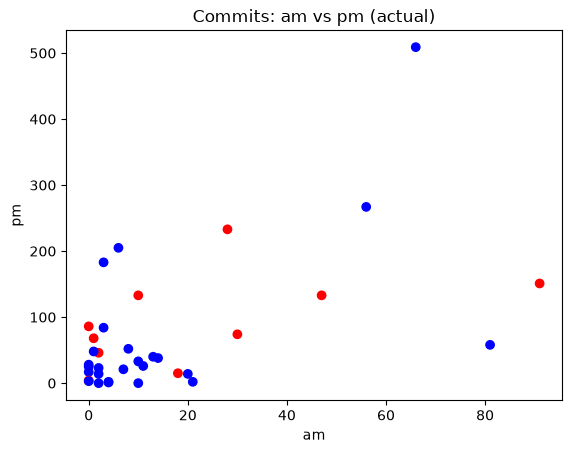

In [9]:
colors = df['target'].map({'working_day': 'blue', 'weekend': 'red'})
plt.scatter(df['am'], df['pm'], c=colors)
plt.xlabel('am')
plt.ylabel('pm')
plt.title('Commits: am vs pm (actual)')
plt.show()

Нет, не просто

## 3. Логистическая регрессия

- Обучи модель логистической регрессии на своих данных, используя `am` и `pm`; параметры: `random state=21`, `fit_intercept=False`.  

- Сделай предсказания для каждого дня из набора данных и добавь их в датафрейм в столбец с именем `predict`.  

- Сохрани датафрейм в файл в подпапке дня `data` под именем `am_pm.csv`.  

- Построй ещё один график, как ранее, но теперь цвет точек должен определяться значениями из столбца `predict`.  

- Посмотрев на график, как ты думаешь, сделала ли модель хорошие предсказания? Напиши свой ответ в markdown-ячейке в конце этого раздела: "Да, хорошие"; "Нет, плохие".

In [10]:
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(df[['am', 'pm']], df['target'])

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

In [11]:
df['predict'] = model.predict(df[['am', 'pm']])

In [12]:
df.to_csv('../data/am_pm.csv', index=False)

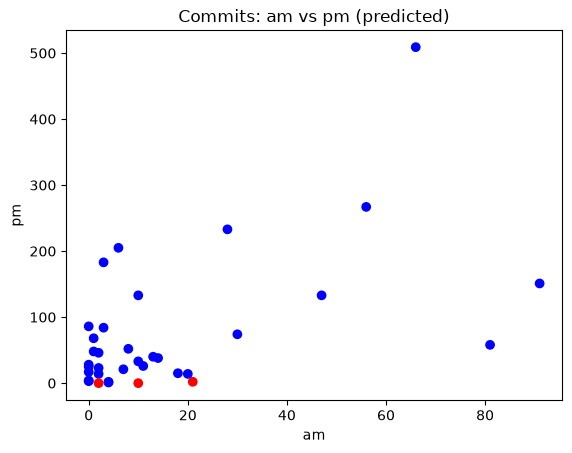

In [13]:
colors_pred = df['predict'].map({'working_day': 'blue', 'weekend': 'red'})
plt.scatter(df['am'], df['pm'], c=colors_pred)
plt.xlabel('am')
plt.ylabel('pm')
plt.title('Commits: am vs pm (predicted)')
plt.show()

Нет, плохие

## 4. Оценка

- Вычисли `accuracy` (точность) для своих предсказаний.  

- Вычисли `accuracy` для наивного случая, когда каждое предсказание — это значение самого популярного класса дня.  

- Сравни значения точности и подумай, сделал ли классификатор хорошие предсказания? Напиши свой ответ в markdown-ячейке в конце этого раздела: "Да, хорошие"; "Нет, плохие".

In [14]:
accuracy = accuracy_score(df['target'], df['predict'])
print(accuracy)

0.6285714285714286


In [15]:
naive_pred = df['target'].value_counts().idxmax()
naive_accuracy = accuracy_score(df['target'], [naive_pred] * len(df))
print(naive_accuracy)

0.7142857142857143


Нет, плохие